In [1]:
import pandas as pd

from prismadv.utils import get_project_root

In [2]:
full_df = pd.read_csv(get_project_root() / "workflow/cad_evaluation/tables/cad_results.csv")
dataset_selections = ["imdb", "IPL_win_prediction", "sleep_health", "hr_analytics", "students"]

/var/folders/19/8dpm1qss7mn34db1f49thmww0000gn/T/ipykernel_95964/3563557125.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16, rotation=0)


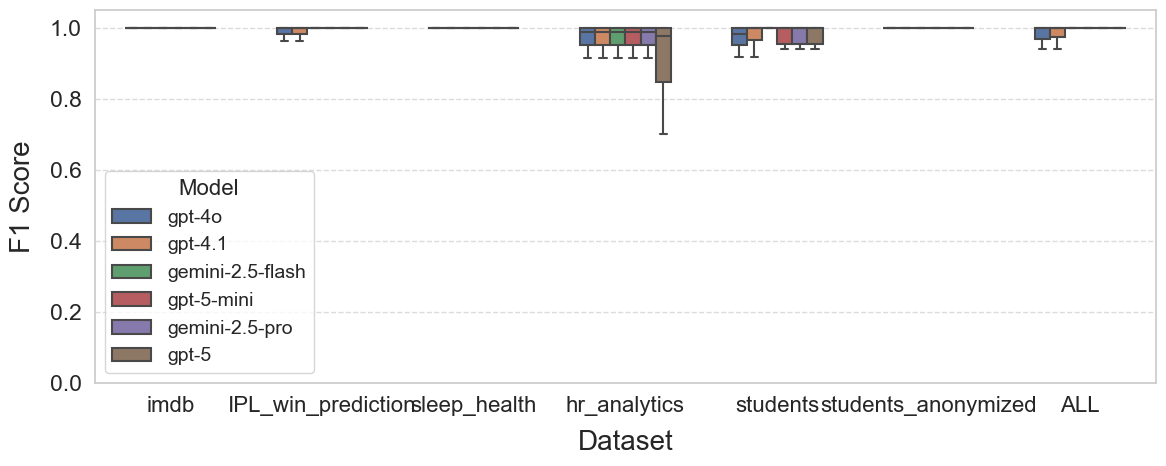

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def plot_f1_boxplots_grouped(full_df, dataset_names=None, savepath="f1_boxplots_grouped.pdf"):
    sns.set_theme(style="whitegrid", font_scale=1.5, rc={"axes.labelsize": 14, "axes.titlesize": 16})

    # optional filter
    if dataset_names is not None:
        full_df = full_df[full_df['dataset_name'].isin(dataset_names)]

    # restrict and order models
    model_order = [
        "gpt-4o",
        "gpt-4.1",
        "gemini-2.5-flash",
        "gpt-5-mini",
        "gemini-2.5-pro",
        "gpt-5"
    ]
    full_df = full_df[full_df['model_name'].isin(model_order)].copy()
    full_df["model_name"] = pd.Categorical(full_df["model_name"], categories=model_order, ordered=True)

    # aggregated "ALL" group
    aggregated = full_df.copy()
    aggregated["dataset_name"] = "ALL"
    full_df = pd.concat([full_df, aggregated], ignore_index=True)

    # x-axis order with ALL last
    if dataset_names is not None:
        ds_order = list(dataset_names) + ["ALL"]
    else:
        ds_order = sorted(full_df.loc[full_df["dataset_name"] != "ALL", "dataset_name"].unique().tolist()) + ["ALL"]
    full_df["dataset_name"] = pd.Categorical(full_df["dataset_name"], categories=ds_order, ordered=True)

    plt.figure(figsize=(12, 5))
    ax = sns.boxplot(
        x="dataset_name",
        y="accessed_columns_f1",
        hue="model_name",
        hue_order=model_order,
        data=full_df,
        width=0.6,
        linewidth=1.5,
        fliersize=2,
        showfliers=False,
    )

    ax.set_ylabel("F1 Score", fontsize=20, labelpad=10)
    ax.set_xlabel("Dataset", fontsize=20, labelpad=10)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=16, rotation=0)
    ax.legend(title="Model", fontsize=14, title_fontsize=16)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylim(0, 1.05)

    plt.tight_layout()
    # plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()


plot_f1_boxplots_grouped(full_df, dataset_names=dataset_selections, savepath="f1_boxplots_grouped_selected.pdf")